In [1]:
# dependencies :
!pip install pretty_midi pillow numpy


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Imports :
import os, random, uuid, math, csv
import numpy as np
import pretty_midi
from pathlib import Path
from PIL import Image

INPUT_FOLDER = "mozart"
SEG_OUTPUT = f"{INPUT_FOLDER}midis"
BMP_OUTPUT = f"{SEG_OUTPUT}bitmap"

os.makedirs(SEG_OUTPUT, exist_ok=True)
os.makedirs(BMP_OUTPUT, exist_ok=True)

BEAT_WINDOW = 28
SEGMENTS_PER_MIDI = 7


def best_28_semitone_window(notes):
    pitches = [n.pitch for n in notes]
    best_low = min(pitches)
    best_count = 0
    for low in range(min(pitches), max(pitches) - 27):
        high = low + 27
        c = sum(low <= p <= high for p in pitches)
        if c > best_count:
            best_low = low
            best_count = c
    return best_low, best_low + 27


In [16]:
# midi slicing
import time

def build_true_melody(notes, start_time, end_time):
    duration = end_time - start_time
    step = duration / 28.0
    melody = []
    for i in range(28):
        s = start_time + i * step
        e = s + step
        active = [n for n in notes if n.start < e and n.end > s]
        melody.append(max(active, key=lambda n: n.pitch).pitch if active else None)

    pm_out = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0)
    t = 0.0
    for pitch in melody:
        if pitch is not None:
            inst.notes.append(pretty_midi.Note(
                pitch=pitch, velocity=95, start=t, end=t+step))
        t += step

    if not inst.notes:
        return None
    pm_out.instruments.append(inst)
    return pm_out

def slice_midi(pm, notes):
    beats = pm.get_beats()
    if len(beats) < BEAT_WINDOW + 1:
        return 0

    used = set()
    made = 0

    start_time = time.time()          # mulai timer
    TIME_LIMIT = 0.1                 # batas 1 detik

    while made < SEGMENTS_PER_MIDI:

        # ⏳ jika lebih dari 10 detik → berhenti
        if time.time() - start_time > TIME_LIMIT:
            break

        idx = random.randint(0, len(beats) - BEAT_WINDOW - 1)
        if idx in used:
            continue
        used.add(idx)

        start = beats[idx]
        end = beats[idx + BEAT_WINDOW]

        slice_notes = [
            n for n in notes
            if not (n.end < start or n.start > end)
        ]

        pm_out = build_true_melody(slice_notes, start, end)
        if pm_out is None:
            continue

        name = f"segment_{uuid.uuid4().hex[:8]}.mid"
        pm_out.write(os.path.join(SEG_OUTPUT, name))
        made += 1

    return made


def process_folder(folder):
    total = 0
    for f in os.listdir(folder):
        if not f.lower().endswith(".mid"):
            continue
        path = os.path.join(folder, f)
        try:
            pm = pretty_midi.PrettyMIDI(path)
        except:
            continue
        if not pm.instruments:
            continue
        notes = pm.instruments[0].notes
        if len(notes) < 5:
            continue
        low, high = best_28_semitone_window(notes)
        filtered = [n for n in notes if low <= n.pitch <= high]
        total += slice_midi(pm, filtered)

    print("MIDI slicing finished")
    print("Saved to:", os.path.abspath(SEG_OUTPUT))
    print("Total segments:", total)


In [17]:
# Convert to bitmap
def midi_to_bitmap(pm, bmp_path):
    if not pm.instruments or not pm.instruments[0].notes:
        return
    notes = pm.instruments[0].notes
    low, high = best_28_semitone_window(notes)

    start_time = min(n.start for n in notes)
    end_time = max(n.end for n in notes)
    duration = end_time - start_time
    if duration <= 0:
        return

    step = duration / 28.0
    grid = np.zeros((28, 28), dtype=np.uint8)

    for note in notes:
        if not (low <= note.pitch <= high):
            continue
        pitch_index = high - note.pitch
        for t in range(28):
            s = start_time + t * step
            e = s + step
            if note.start < e and note.end > s:
                grid[pitch_index, t] = 255

    Image.fromarray(grid, mode="L").save(bmp_path)


def convert_segments_to_bitmaps():
    for file in os.listdir(SEG_OUTPUT):
        if not file.lower().endswith(".mid"):
            continue
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(SEG_OUTPUT, file))
        except:
            continue

        out_path = os.path.join(
            BMP_OUTPUT, os.path.splitext(file)[0] + ".bmp"
        )
        midi_to_bitmap(pm, out_path)

    print("Bitmap conversion done")
    print("Saved to:", os.path.abspath(BMP_OUTPUT))


In [22]:
print("=== PREPROCESSING PIPELINE ===")

# 1) Proses folder MIDI asli
print("\n[ STEP 1 ] Slice MIDI Input")
process_folder(INPUT_FOLDER)

# 2) Proses lagi folder hasil slicing agar dataset makin banyak
print("\n[ STEP 2 ] Slice Folder Hasil")
process_folder(SEG_OUTPUT)

# 3) Convert semua .mid -> .bmp
print("\n[ STEP 3 ] Convert MIDIs ke Bitmap 28x28")
convert_segments_to_bitmaps()



=== PREPROCESSING PIPELINE ===

[ STEP 1 ] Slice MIDI Input
MIDI slicing finished
Saved to: C:\Users\denni\desktop\midi-test\mozartmidis
Total segments: 147

[ STEP 2 ] Slice Folder Hasil
MIDI slicing finished
Saved to: C:\Users\denni\desktop\midi-test\mozartmidis
Total segments: 571

[ STEP 3 ] Convert MIDIs ke Bitmap 28x28
Bitmap conversion done
Saved to: C:\Users\denni\desktop\midi-test\mozartmidisbitmap


Loading dataset...
Found 718 images
 Loading image 0/718 -> segment_001a01c3.bmp
 Loading image 200/718 -> segment_4d2249ad.bmp
 Loading image 400/718 -> segment_961a7c6f.bmp
 Loading image 600/718 -> segment_d7d63b3d.bmp
Dataset shape: torch.Size([718, 784])
Device: cuda
Start training...
[Epoch 1/300] C=-1.7280  G=0.0498
[Epoch 2/300] C=-7.5545  G=0.0400
[Epoch 3/300] C=-20.0960  G=-0.1382
[Epoch 4/300] C=-38.8880  G=-0.7444
[Epoch 5/300] C=-52.4993  G=-1.8108
[Epoch 6/300] C=-55.7557  G=-2.6868
[Epoch 7/300] C=-55.2318  G=-3.1059
[Epoch 8/300] C=-54.9115  G=-3.7042
[Epoch 9/300] C=-54.0411  G=-4.4640
[Epoch 10/300] C=-53.3581  G=-5.1977
[Epoch 11/300] C=-52.4268  G=-5.8925
[Epoch 12/300] C=-51.6804  G=-6.7673
[Epoch 13/300] C=-50.7400  G=-7.6593
[Epoch 14/300] C=-49.8210  G=-8.3757
[Epoch 15/300] C=-49.1131  G=-9.1452
[Epoch 16/300] C=-47.9903  G=-9.9988
[Epoch 17/300] C=-46.8800  G=-10.9532
[Epoch 18/300] C=-45.6591  G=-11.6930
[Epoch 19/300] C=-44.6502  G=-12.7675
[Epoch 20/300] C

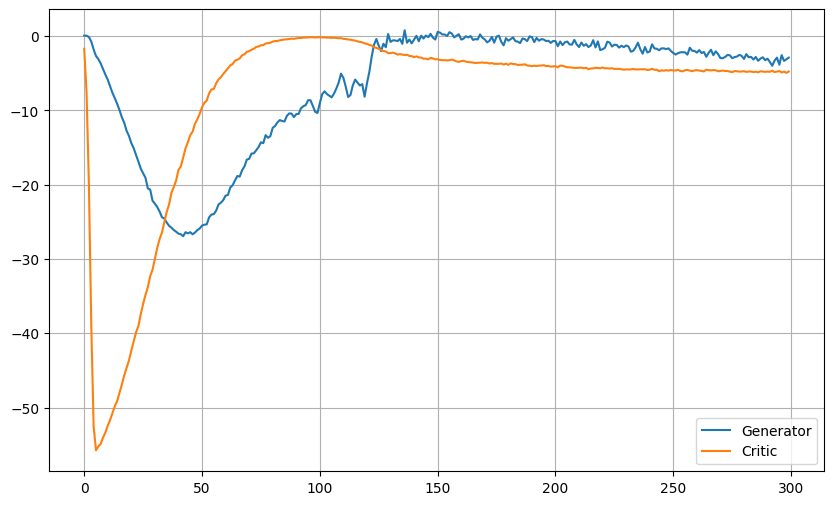

Training complete.


In [23]:
# ======================= WGAN + MIDI + Q6.10 WEIGHT MEM DUMP ==========================
import os
import uuid
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
import pretty_midi
import copy
from torch.utils.data import TensorDataset, DataLoader

# ================= CONFIG =================
CONFIG = {
    "DATASET": "mozartmidisbitmap",
    "EPOCHS": 300,
    "BATCH_SIZE": 200,   
    "LATENT": 64,

    "FOLDER_PREVIEW": "WGAN_preview_images",
    "FOLDER_MIDI": "WGAN_preview_midi",
    "FOLDER_MEM_WEIGHTS": "WGAN_mem_weights"
}

for f in [
    CONFIG["FOLDER_PREVIEW"],
    CONFIG["FOLDER_MIDI"],
    CONFIG["FOLDER_MEM_WEIGHTS"]
]:
    os.makedirs(f, exist_ok=True)


# ================= LOAD DATASET =================
def load_bitmap_folder(folder):
    files = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(".bmp") or f.lower().endswith(".png")
    ])

    print("Found", len(files), "images")
    if len(files) == 0:
        raise RuntimeError("No 28x28 images found!")

    data = []
    for i, f in enumerate(files):
        if i % 200 == 0:
            print(f" Loading image {i}/{len(files)} -> {f}")

        img = Image.open(os.path.join(folder, f)).convert("L")
        img = img.resize((28, 28))
        arr = np.array(img, dtype=np.float32)

        arr = arr / 255.0
        arr = arr * 2 - 1
        data.append(arr.flatten())

    return np.array(data)


print("Loading dataset...")
dataset_np = load_bitmap_folder(CONFIG["DATASET"])

dataset_tensor = torch.tensor(dataset_np, dtype=torch.float32)

loader = DataLoader(
    dataset_tensor,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset shape:", dataset_tensor.shape)


# ================= GENERATOR =================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(CONFIG["LATENT"], 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 784)
        self.act = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, z):
        x = self.act(self.l1(z))
        x = self.act(self.l2(x))
        return self.tanh(self.l3(x))


# ================= CRITIC =================
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(784, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 256)
        self.l4 = nn.Linear(256, 1)
        self.leaky = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.leaky(self.l1(x))
        x = self.leaky(self.l2(x))
        x = self.leaky(self.l3(x))
        return self.l4(x)


# ================= LIPSCHITZ =================
def lipschitz_penalty(C, real, fake, device, lambda_lp=5):
    alpha = torch.rand(real.size(0), 1).to(device)
    alpha = alpha.expand_as(real)

    interpolated = alpha * real + (1 - alpha) * fake
    interpolated = interpolated.detach().requires_grad_(True)

    score = C(interpolated)

    grads = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad_norm = grads.view(grads.size(0), -1).norm(2, dim=1)
    lp = torch.relu(grad_norm - 1) ** 2
    return lambda_lp * lp.mean()


# ================= Q6.10 EXPORT =================
def float_to_q6_10_hex(v):
    v = max(-1.0, min(1.0, float(v)))
    scaled = int(round(v * 1024))
    scaled = max(-32768, min(32767, scaled))
    return f"{scaled & 0xFFFF:04X}"


def export_layer_q610(layer, name, epoch):
    W = layer.weight.data.cpu().numpy().flatten()
    B = layer.bias.data.cpu().numpy().flatten()

    base = os.path.join(CONFIG["FOLDER_MEM_WEIGHTS"],
                        f"epoch{epoch:03d}_{name}")

    with open(base + "_W.mem", "w") as fw:
        for v in W:
            fw.write(float_to_q6_10_hex(v) + "\n")

    with open(base + "_B.mem", "w") as fb:
        for v in B:
            fb.write(float_to_q6_10_hex(v) + "\n")

    print("Exported", name)


def export_all_q610(G, C, epoch):
    export_layer_q610(G.l1, "G_l1", epoch)
    export_layer_q610(G.l2, "G_l2", epoch)
    export_layer_q610(G.l3, "G_l3", epoch)

    export_layer_q610(C.l1, "C_l1", epoch)
    export_layer_q610(C.l2, "C_l2", epoch)
    export_layer_q610(C.l3, "C_l3", epoch)
    export_layer_q610(C.l4, "C_l4", epoch)


# ================= MIDI CONVERSION =================
LOW_PITCH = 60
HIGH_PITCH = LOW_PITCH + 27
TEMPO = 120


def safe_write_midi(pm, filename):
    base = filename
    attempts = 0
    while attempts < 5:
        try:
            pm.write(filename)
            return
        except:
            filename = base.replace(".mid", f"_{uuid.uuid4().hex[:4]}.mid")
            attempts += 1


def bitmap_to_midi(grid, filename):
    raw = grid.copy()
    mask = (grid > 0.35).astype(np.uint8)

    active_cols = [c for c in range(28) if mask[:, c].sum() > 0]

    if len(active_cols) < 16:
        cols = [(c, raw[:, c].max()) for c in range(28)]
        cols.sort(key=lambda x: x[1], reverse=True)

        for c, _ in cols:
            if c not in active_cols:
                active_cols.append(c)
            if len(active_cols) >= 16:
                break

        mask = np.zeros_like(mask)
        for c in active_cols:
            row = np.argmax(raw[:, c])
            mask[row, c] = 1

    pm = pretty_midi.PrettyMIDI(initial_tempo=TEMPO)
    inst = pretty_midi.Instrument(program=0)

    for c in sorted(active_cols):
        rows = np.where(mask[:, c] == 1)[0]
        if len(rows) == 0:
            continue
        row = rows[0]
        pitch = HIGH_PITCH - row
        start = c * (60 / TEMPO)
        end = (c + 1) * (60 / TEMPO)
        inst.notes.append(pretty_midi.Note(pitch=pitch, velocity=95, start=start, end=end))

    pm.instruments.append(inst)
    safe_write_midi(pm, filename)


# ================= TRAIN =================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

G = Generator().to(device)
C = Critic().to(device)

optim_G = optim.Adam(G.parameters(), lr=0.00005, betas=(0.5, 0.9))
optim_C = optim.Adam(C.parameters(), lr=0.00005, betas=(0.5, 0.9))

CRITIC_ITERS = 10
loss_G_list = []
loss_C_list = []

G_EMA = copy.deepcopy(G)


def update_ema(G_EMA, G, decay=0.995):
    for p_ema, p in zip(G_EMA.parameters(), G.parameters()):
        p_ema.data = decay * p_ema.data + (1 - decay) * p.data


def save_grid(imgs, filename):
    imgs = imgs.cpu().detach().numpy().reshape(-1, 28, 28)
    img_big = Image.new("L", (28*3, 28*3))
    idx = 0
    for r in range(3):
        for c in range(3):
            tile = (imgs[idx] + 1) / 2 * 255
            tile = tile.astype(np.uint8)
            im = Image.fromarray(tile, mode="L")
            img_big.paste(im, (c*28, r*28))
            idx += 1
    img_big.save(filename)


print("Start training...")
fixed_z = torch.randn(9, CONFIG["LATENT"]).to(device)

for epoch in range(CONFIG["EPOCHS"]):

    for step, real in enumerate(loader):

        if step >= 16:      # 
            break

        real = real.to(device)
        b = real.size(0)
        real_noisy = real + torch.randn_like(real) * 0.02

        # ----- Critic -----
        for _ in range(CRITIC_ITERS):
            z = torch.randn(b, CONFIG["LATENT"]).to(device)
            fake = G(z).detach()

            critic_real = C(real_noisy)
            critic_fake = C(fake)

            wasserstein = -(critic_real.mean() - critic_fake.mean())
            lp = lipschitz_penalty(C, real, fake, device)
            loss_C = wasserstein + lp

            optim_C.zero_grad()
            loss_C.backward()
            optim_C.step()

        # ----- Generator -----
        z = torch.randn(b, CONFIG["LATENT"]).to(device)
        fake = G(z)
        loss_G = -C(fake).mean()

        optim_G.zero_grad()
        loss_G.backward()
        optim_G.step()

        update_ema(G_EMA, G)

    loss_G_list.append(loss_G.item())
    loss_C_list.append(loss_C.item())

    print(f"[Epoch {epoch+1}/{CONFIG['EPOCHS']}] C={loss_C.item():.4f}  G={loss_G.item():.4f}")

    if (epoch + 1) % 50 == 0:
        samples = G_EMA(fixed_z)

        img_path = f"{CONFIG['FOLDER_PREVIEW']}/preview_epoch_{epoch+1}.png"
        save_grid(samples, img_path)

        arr = samples.cpu().detach().numpy().reshape(-1, 28, 28)
        for idx, g in enumerate(arr):
            midi_out = f"{CONFIG['FOLDER_MIDI']}/epoch{epoch+1}_sample{idx+1}.mid"
            bitmap_to_midi((g + 1) / 2, midi_out)

export_all_q610(G_EMA, C, epoch + 1)


# ================= LOSS PLOT =================
plt.figure(figsize=(10,6))
plt.plot(loss_G_list, label="Generator")
plt.plot(loss_C_list, label="Critic")
plt.grid(True)
plt.legend()
plt.savefig("loss_wgan_lp.png")
plt.show()

print("Training complete.")
